Costruzione del QC con Toffoli gate

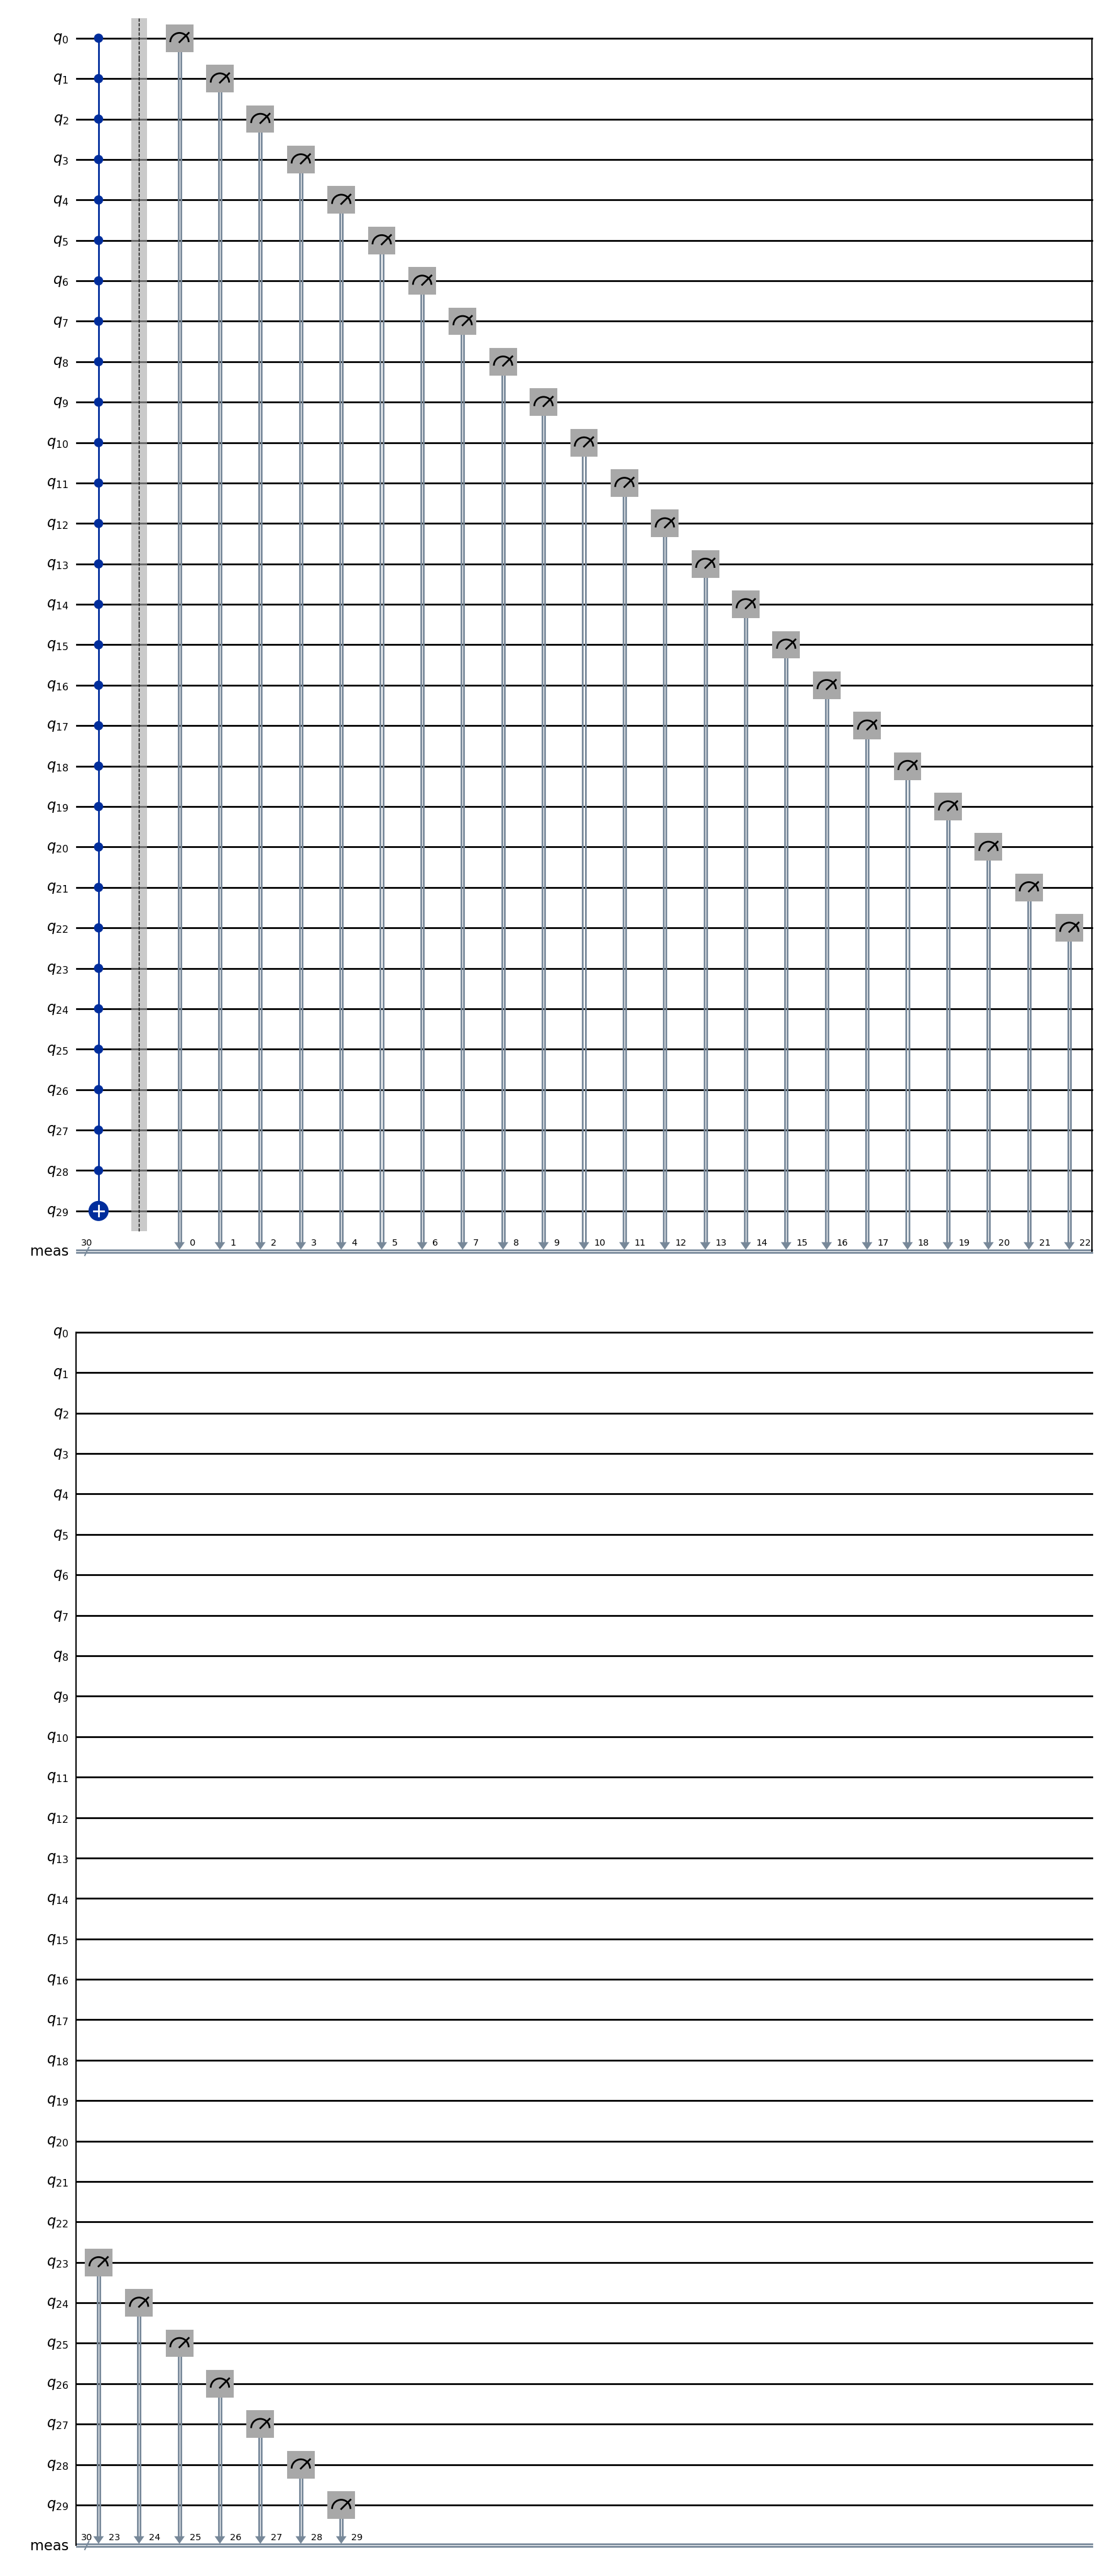

In [1]:
from qiskit import QuantumCircuit, transpile

n = 30
qc = QuantumCircuit(n)

# Aggiungiamo un gate Toffoli con 29 controlli e un target
qc.mcx(list(range(n-1)), n-1)
qc.measure_all()
# Disegniamo il circuito
qc.draw("mpl")


Costruisco il simulatore partendo dalla backend fisica backend_kingston

In [2]:
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit_aer.noise import NoiseModel

# Simuleremo il nostro circuito utilizzando come riferimento IBM_kingston
service = QiskitRuntimeService()
backend_kingston = service.backend('ibm_kingston')
noise_model = NoiseModel.from_backend(backend_kingston)
# Simulatore con modello del rumore preso da IBM_kingston
noise_kingston_sim = AerSimulator(noise_model=noise_model)


qiskit_runtime_service.__init__:WARNING:2026-04-02 16:13:26,540: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-02 16:13:26,541: Using instance: open-instance, plan: open


Differenza nei gate utilizzati per i 4 transpile

In [3]:
qc_transpiled_0 = transpile(qc, backend_kingston, optimization_level=0)
qc_transpiled_1 = transpile(qc, backend_kingston, optimization_level=1)
qc_transpiled_2 = transpile(qc, backend_kingston, optimization_level=2)
qc_transpiled_3 = transpile(qc, backend_kingston, optimization_level=3)
print("\nDifferenza nei gate usati:")
print("optimization_level=0",qc_transpiled_0.count_ops())
print("optimization_level=1",qc_transpiled_1.count_ops())
print("optimization_level=1",qc_transpiled_2.count_ops())
print("optimization_level=3",qc_transpiled_3.count_ops())


Differenza nei gate usati:
optimization_level=0 OrderedDict({'sx': 37508, 'rz': 18815, 'cz': 18305, 'x': 260, 'measure': 30, 'barrier': 1})
optimization_level=1 OrderedDict({'sx': 22276, 'rz': 12887, 'cz': 11714, 'measure': 30, 'x': 16, 'barrier': 1})
optimization_level=1 OrderedDict({'sx': 20505, 'cz': 10285, 'rz': 8574, 'x': 45, 'measure': 30, 'barrier': 1})
optimization_level=3 OrderedDict({'sx': 21302, 'cz': 10728, 'rz': 8690, 'x': 53, 'measure': 30, 'barrier': 1})


Esecuzione su hardware reale backend_kingston con i 4 livelli di optimization_level

qc_transpiled = transpile(qc, backend_kingston, optimization_level=0,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

qc_transpiled = transpile(qc, backend_kingston, optimization_level=1,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

qc_transpiled = transpile(qc, backend_kingston, optimization_level=2,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

qc_transpiled = transpile(qc, backend_kingston, optimization_level=3,scheduling_method="alap")
sampler = SamplerV2(backend_kingston)
job_real = sampler.run([qc_transpiled], shots=1000)
print("Job ID:", job_real.job_id())

Recupero dei dati delle esecuzioni su hardware reale

In [ ]:
job_id = 'xxxxxxxxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_0=job_real.result()

job_id = 'xxxxxxxxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_1=job_real.result()

job_id = 'xxxxxxxxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_2=job_real.result()

job_id = 'xxxxxxxxxxxxxxxxxxxxxxxx'
job_real=service.job(job_id)
results_real_3=job_real.result()

Confronto dei rumori in base ai diversi gradi di Optimization_Level

In [4]:
# Codice analogo a quello con simulatore
counts = results_real_0[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get) 
max_prob_value = probabilities[max_prob_state]  
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_0 = {max_prob_state: max_prob_value, 'noise': noises_prob}

counts = results_real_1[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get)  
max_prob_value = probabilities[max_prob_state] 
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_1 = {max_prob_state: max_prob_value, 'noise': noises_prob}

counts = results_real_2[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get)  
max_prob_value = probabilities[max_prob_state] 
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_2 = {max_prob_state: max_prob_value, 'noise': noises_prob}

counts = results_real_3[0].data.meas.get_counts()
probabilities = {key: value / 10000 for key, value in counts.items()}
max_prob_state = max(probabilities, key=probabilities.get)  
max_prob_value = probabilities[max_prob_state] 
noises_prob = sum(prob for state, prob in probabilities.items() if state != max_prob_state) 
probabilities_level_3 = {max_prob_state: max_prob_value, 'noise': noises_prob}

data = [probabilities_level_0,probabilities_level_1,probabilities_level_2, probabilities_level_3]
legend_labels = ["Optimization_Level=0", "Optimization_Level=1","Optimization_Level=2", "Optimization_Level=3"]
plot_histogram(data, legend=legend_labels, title="Confronto rumori con diversi Optimization_Level")


NameError: name 'results_real_0' is not defined

Profondità del QC e #Gates in base ai 4 livelli di ottimizzazione di Qiskit

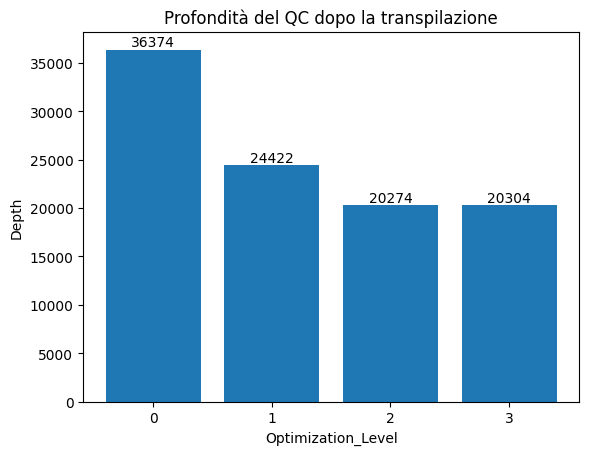

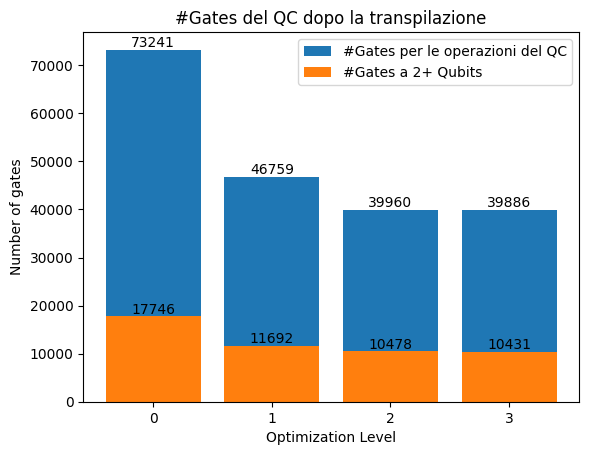

In [5]:
import matplotlib.pyplot as plt
depths = [0,0,0,0]
gate_counts = [0,0,0,0]
non_local_gate_counts = [0,0,0,0]
levels = ["0", "1", "2", "3"]

# Eseguo la traspilazione sempre basata su ibm_kingston e raccolgo la profondità e #Gates per ogni optimization_level facendo una media su 10 transpilazioni
for i in range(10):
    for level in range(4):
        circ = transpile(qc, backend_kingston, optimization_level=level)
        depths[level] += circ.depth()
        gate_counts[level] += sum(circ.count_ops().values())
        non_local_gate_counts[level] += circ.num_nonlocal_gates()
        
for i in range(4):
    depths[i] = round(depths[i]/10)
    gate_counts[i] = round(gate_counts[i]/10)
    non_local_gate_counts[i] = round(non_local_gate_counts[i]/10)

# Grafico per la Profondità
plt.figure()
bars = plt.bar(levels, depths, label='Depth')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.xlabel("Optimization_Level")
plt.ylabel("Depth")
plt.title("Profondità del QC dopo la transpilazione")
plt.show()
# Grafico per il #Gates
plt.figure()
bars = plt.bar(levels, gate_counts, label='#Gates per le operazioni del QC')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
bars = plt.bar(levels, non_local_gate_counts, label='#Gates a 2+ Qubits ')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', fontsize=10)
plt.xlabel("Optimization Level")
plt.ylabel("Number of gates")
plt.legend()
plt.title("#Gates del QC dopo la transpilazione")
plt.show()

Confronto dei tempi di esecuzione in base ai diversi 'Optimization_Level' sfruttando 'scheduled_circuit' prendendo come riferimento sempre ibm_kingston

In [7]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

exec_times = [0,0,0,0]

# Eseguo 5 schedulazioni per ogni 'optimization_level' e prenderò la media di esecuzione

for l in range(4):
    for i in range(5):
        scheduled_circuit = transpile(qc, backend=backend_kingston, optimization_level=l, scheduling_method="alap")
        circuit_duration = scheduled_circuit.duration * backend_kingston.configuration().dt
        exec_times[l] += circuit_duration*1000*1000*1000

print("Tempo di esecuzione con 'optimization_level=0'  {:}[ns]".format(exec_times[0]/5))
print("Tempo di esecuzione con 'optimization_level=1'  {:}[ns]".format(exec_times[1]/5))
print("Tempo di esecuzione con 'optimization_level=2'  {:}[ns]".format(exec_times[2]/5))
print("Tempo di esecuzione con 'optimization_level=3'  {:}[ns]".format(exec_times[3]/5))


Tempo di esecuzione con 'optimization_level=0'  1205874.4000000001[ns]
Tempo di esecuzione con 'optimization_level=1'  854110.4[ns]
Tempo di esecuzione con 'optimization_level=2'  782529.6[ns]
Tempo di esecuzione con 'optimization_level=3'  780981.6[ns]
